In [1]:
import numpy
import pandas
from src.data_objects import AllData
from src.functions import *
from src.readers import ReadDesign

retrain = False
runchain = False
logTrain = True

ThisData = AllData
ThisData["name"] = "pp2760"

model_par = "input/ppDesign.txt"
outdir = "/data/rjfgroup/rjf01/cameron.parker/tunes/" + ThisData["name"] + "/"

ThisData["Design"] = ReadDesign("/data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC2760/QVir_Analysis/parameters.txt")

No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/PionSpectraPredictionSoft
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/PionSpectraPredictionHard
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/KaonSpectraPredictionSoft
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/KaonSpectraPredictionHard
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/ProtonSpectraPredictionSoft
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/ProtonSpectraPredictionHard
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/LowYJetPrediction
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000/QVir_Analysis/MidYJetPrediction
No file matching /data/rjfgroup/rjf01/cameron.parker/runs/part-prop/LHC13000

Trimming points and obs ranges

In [2]:
del ThisData["Observables"]["EpEm91"]

#AllData["Observables"]["PrPr2760"]["pion-pT"]["cuts"] = [np.s_[31:]]
#AllData["Observables"]["PrPr2760"]["kaon-pT"]["cuts"] = [np.s_[26:]]
#AllData["Observables"]["PrPr2760"]["proton-pT"]["cuts"] = [np.s_[24:]]

#AllData["Observables"]["PrPr13000"]["pion-pT"]["cuts"] = [np.s_[21:]]
#AllData["Observables"]["PrPr13000"]["proton-pT"]["cuts"] = [np.s_[29:]] 

del AllData["Observables"]["PrPr13000"]

trimRanges(ThisData)

In [3]:
badpoints = []
trimPoints(badpoints,ThisData)

Making Data pkl for selected observables

In [4]:
buildDataPkl(ThisData, logTrain)
print(ThisData["datapkl"])

Data sets being added to pkl:
PrPr2760charged-pT-soft
PrPr2760charged-pT-hard
PrPr2760pion-pT-soft
PrPr2760pion-pT-hard
PrPr2760kaon-pT-soft
PrPr2760kaon-pT-hard
PrPr2760proton-pT-soft
PrPr2760proton-pT-hard
PrPr2760jets-R2
PrPr2760jets-R3
PrPr2760jets-R4
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/pp2760/data.pkl


Getting emulators

In [5]:
from src.emulator_BAND import EmulatorBAND

setEmuPaths(ThisData)

if retrain:
    buildObsPkls(ThisData)
    trainEmulators(model_par, ThisData, logTrain)
else:
    readEmulators(ThisData)

Running Chain

In [6]:
from src.mcmc import Chain
import os

mcmcpath = "mcmc/" + ThisData["name"] + "-chain.pkl"
mymcmc = Chain(mcmc_path=mcmcpath, expdata_path=ThisData["datapkl"], model_parafile=model_par)
mymcmc.loadEmulator(getEmuPathList(ThisData))

[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/pp2760-chain.pkl
[INFO][mcmc] Loading the model parameters space from input/ppDesign.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/pp2760/data.pkl ...
[INFO][mcmc] Experimental dataset size: 198
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp2760/PrPr2760charged-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp2760/PrPr2760charged-pT-hard-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp2760/PrPr2760pion-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp2760/PrPr2760pion-pT-hard-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp2760/PrPr2760kaon-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Ba

In [7]:
os.environ["OMP_NUM_THREADS"] = "20"
# may have to: export RDMAV_FORK_SAFE=1 before running the code

n_effective=4000
n_active=2000
n_prior=8000
sample="tpcn"
n_max_steps=100
random_state=42

n_total = 25000
n_evidence = 0

pool = 20

if runchain:
    sampler = mymcmc.run_pocoMC(n_effective=n_effective, n_active=n_active,
                            n_prior=n_prior, sample=sample,
                            n_max_steps=n_max_steps, random_state=random_state,
                            n_total=n_total, n_evidence=n_evidence, pool=pool)

Corner Plot

[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours


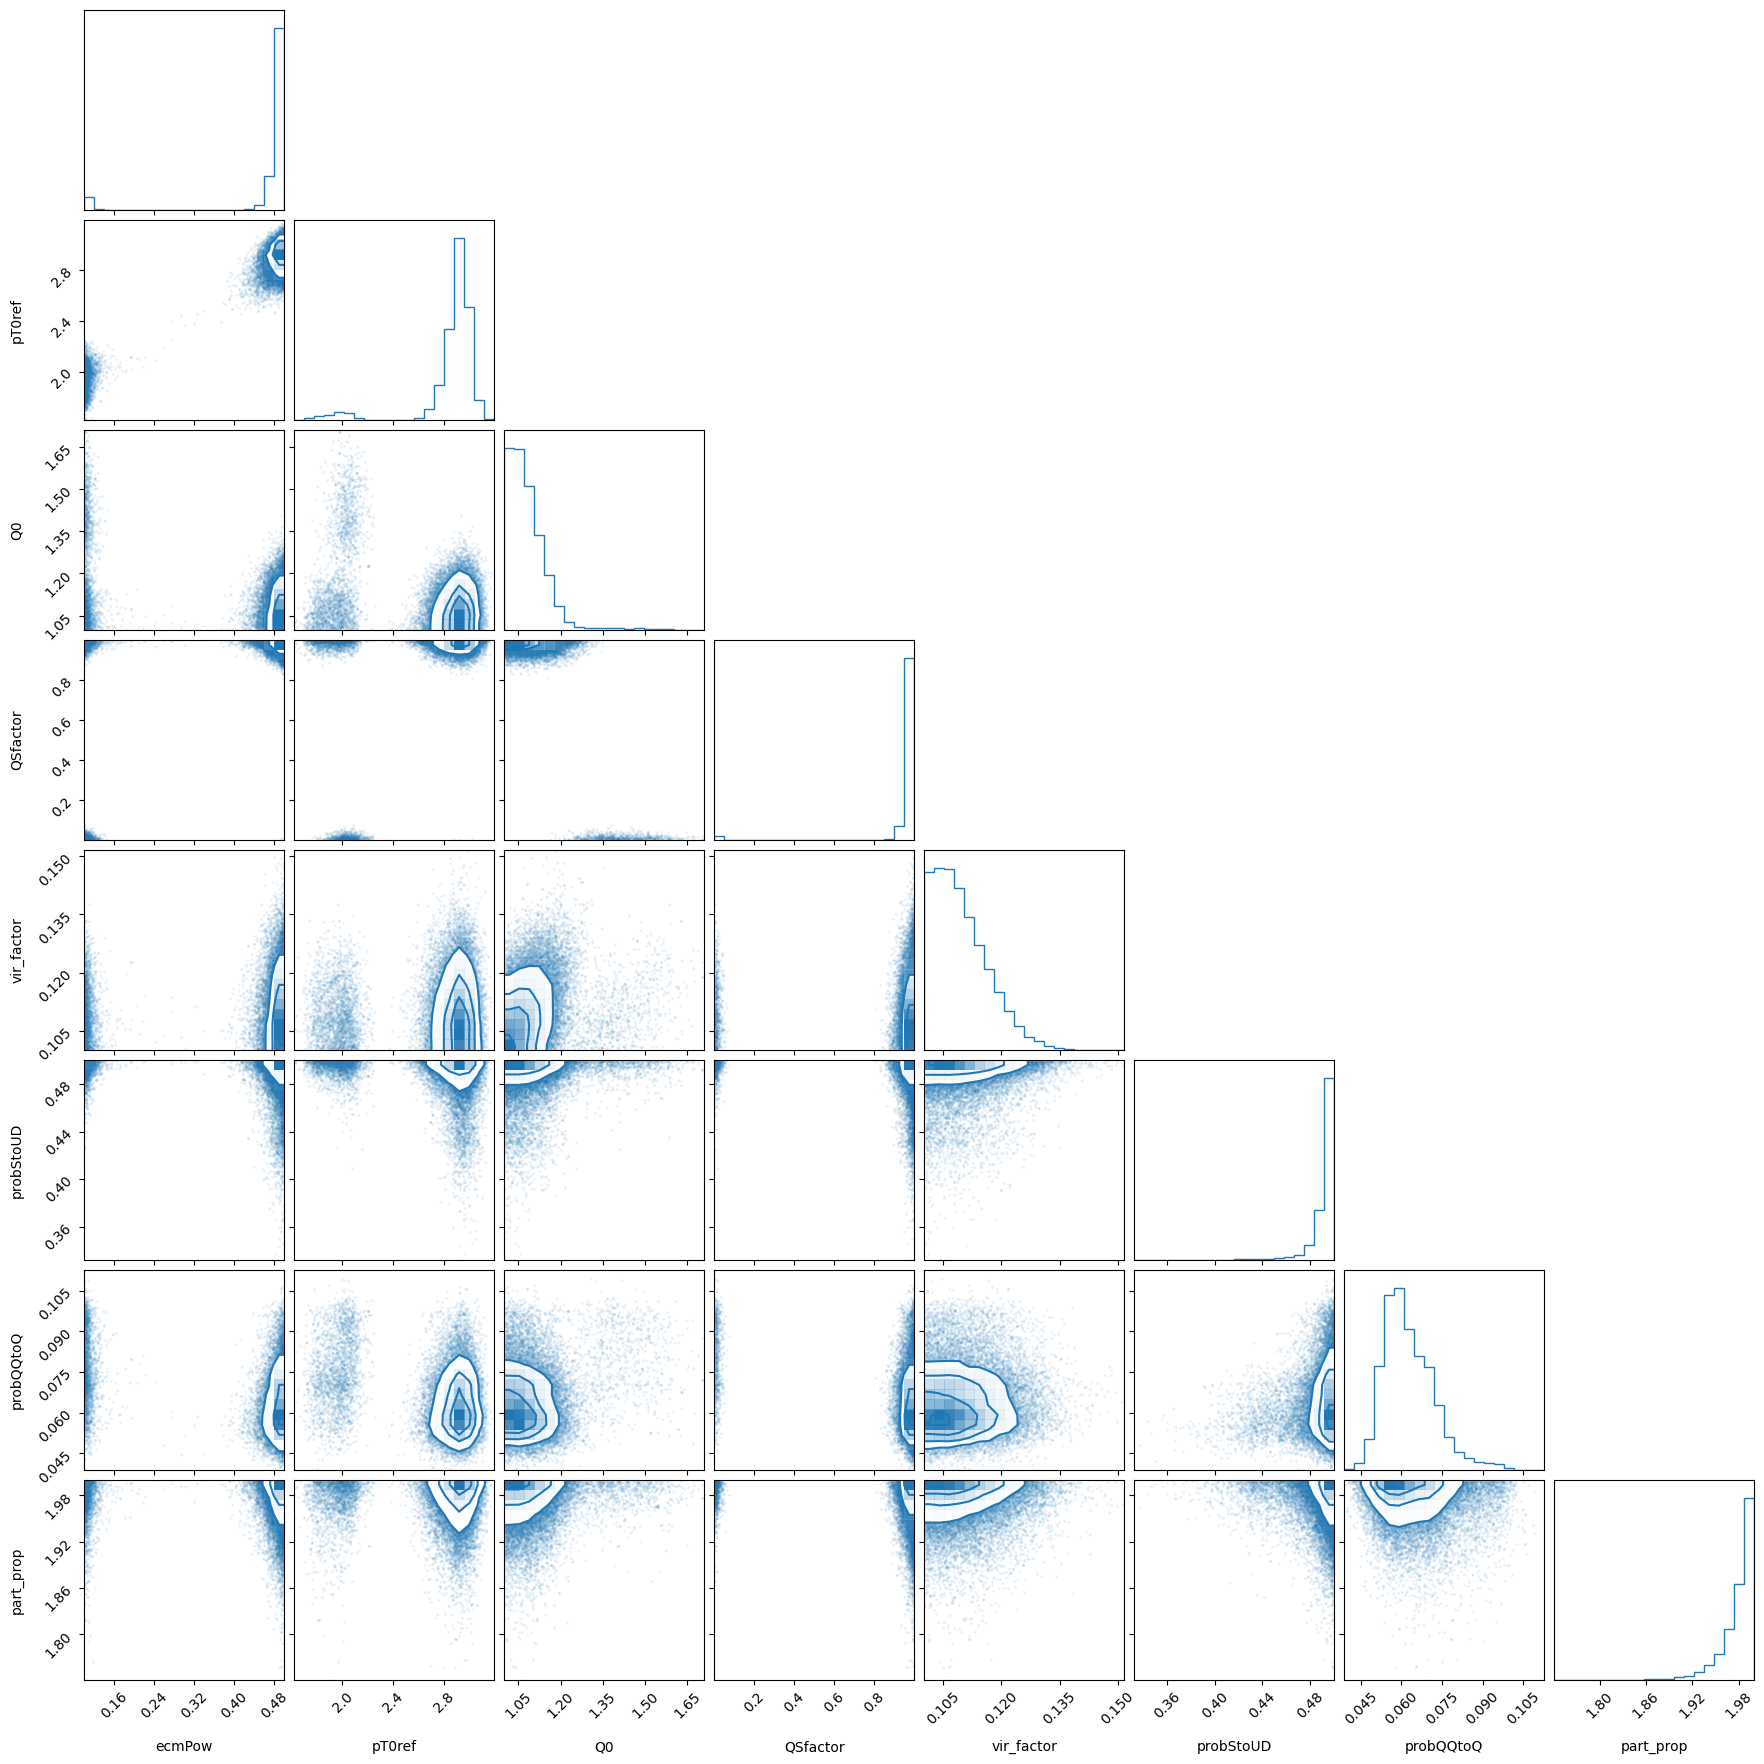

In [8]:
import pickle
import corner
import matplotlib.pyplot as plt
import numpy as np
        
with open(mcmcpath, 'rb') as pf:
        data = pickle.load(pf)

labels = mymcmc.label

fig = corner.corner(data['chain'], weights=data['weights'], labels=labels, color="C0")
plt.show()

[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours


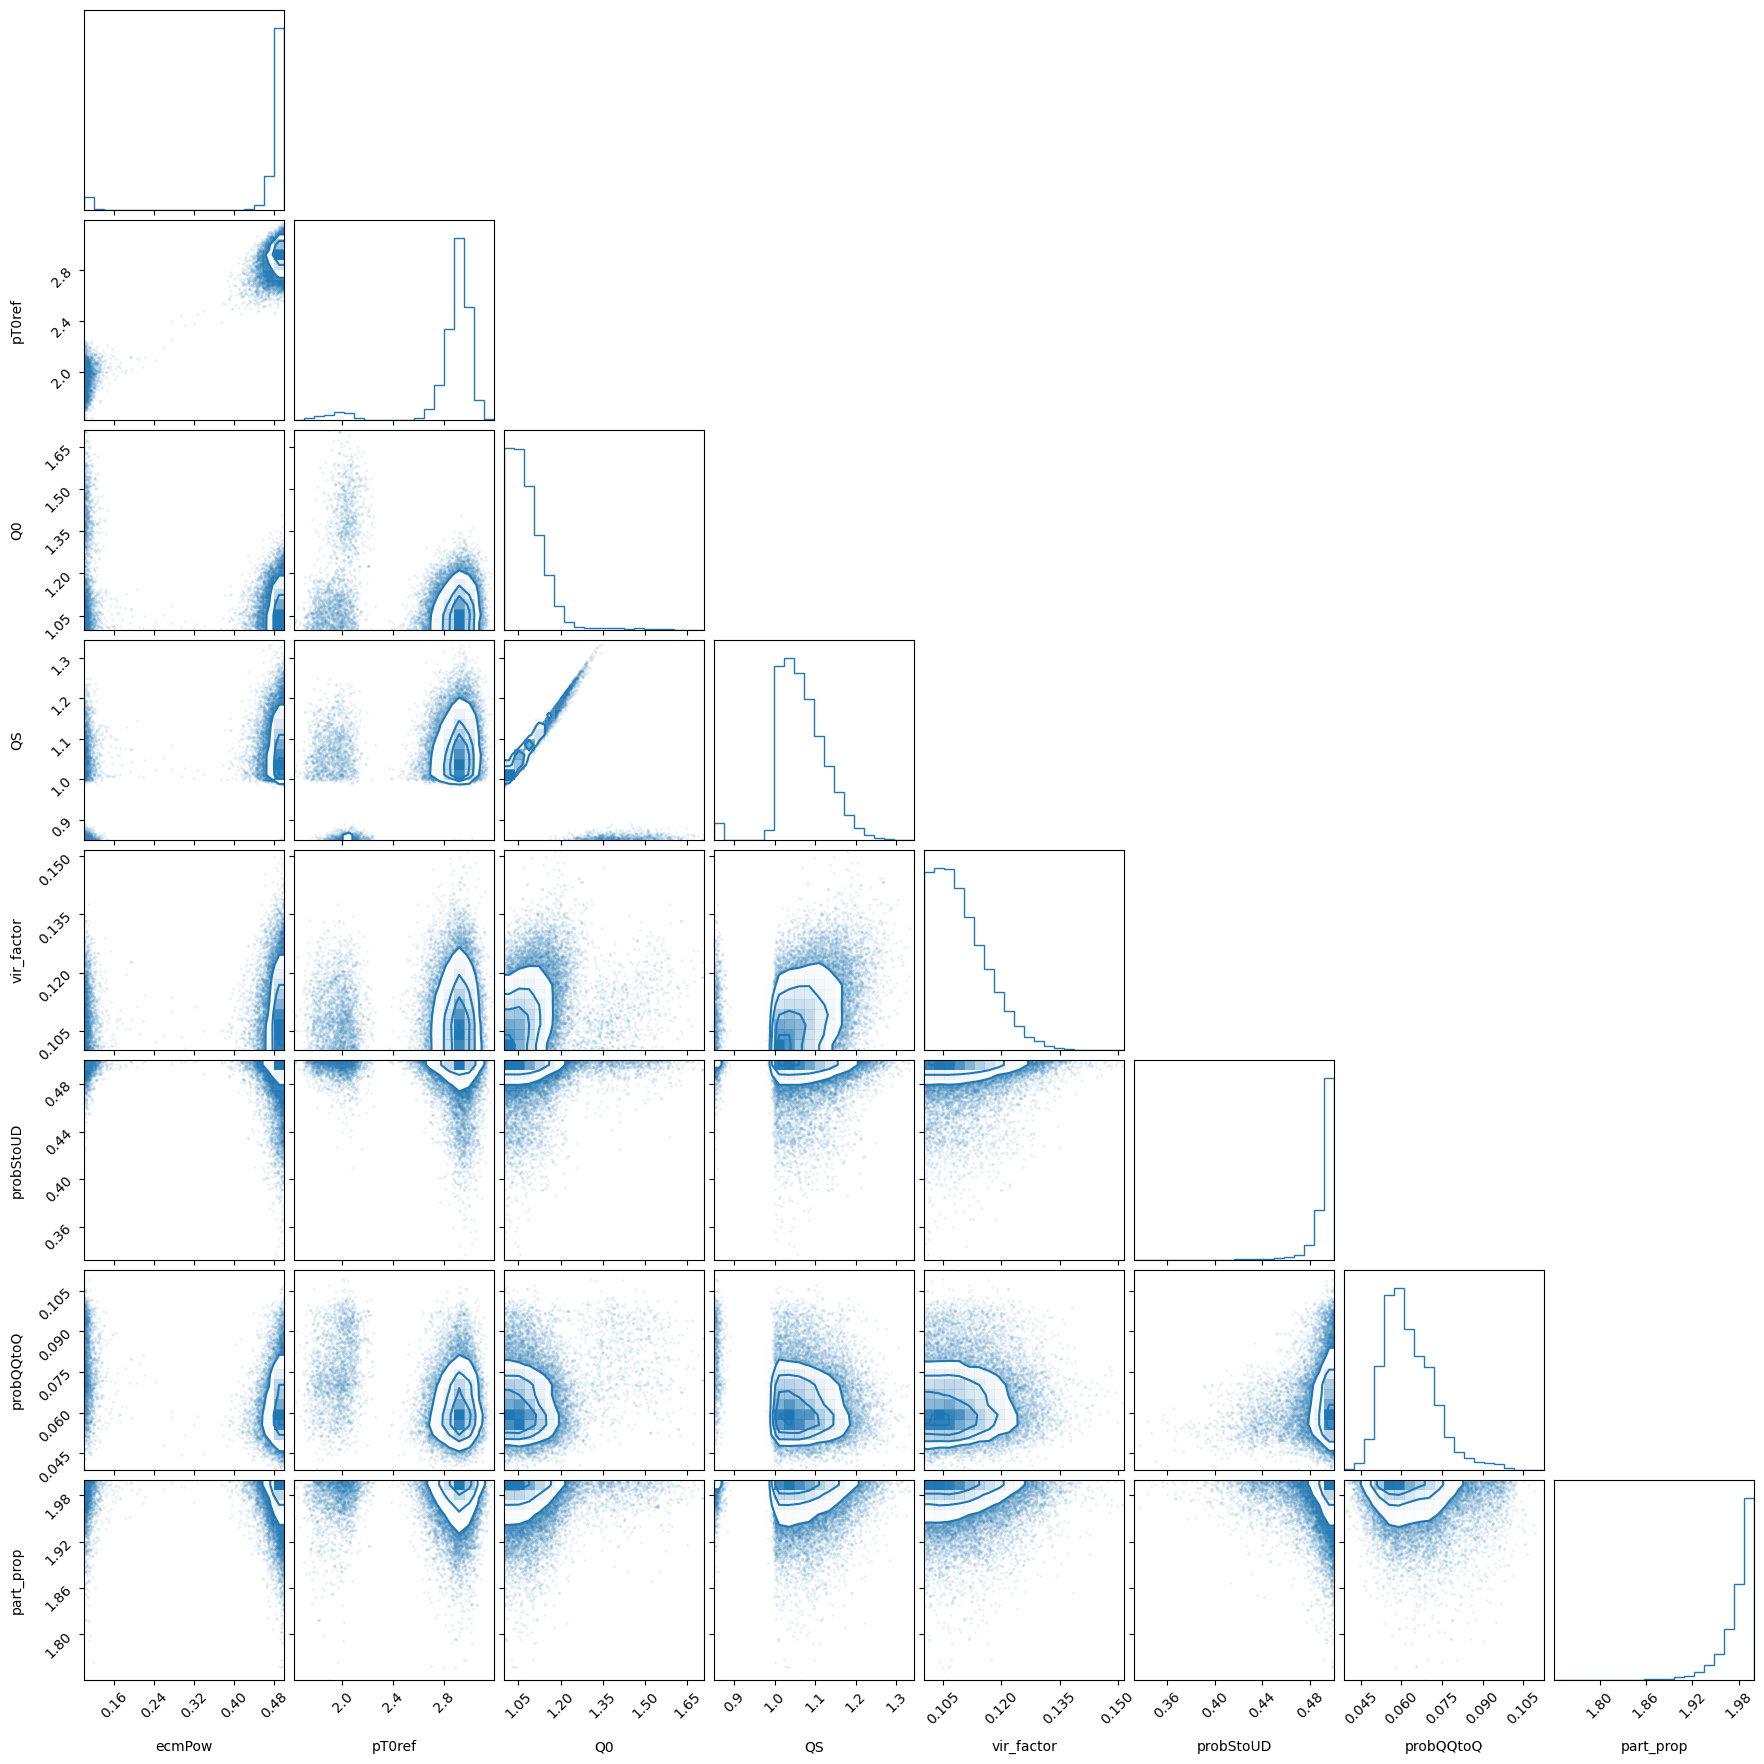

In [9]:
TransformedSamples = np.copy(data['chain'])
TransformedSamples[:,0] = data['chain'][:,0]
TransformedSamples[:,1] = data['chain'][:,1]
TransformedSamples[:,2] = data['chain'][:,2]
TransformedSamples[:,3] = (2*0.4+0.05) + (data['chain'][:,2]-(2*0.4+0.05))*data['chain'][:,3]
TransformedSamples[:,4] = data['chain'][:,4]
TransformedSamples[:,5] = data['chain'][:,5]
TransformedSamples[:,6] = data['chain'][:,6]
TransformedSamples[:,7] = data['chain'][:,7]

labels[3] = "QS"
fig = corner.corner(TransformedSamples, weights=data['weights'], labels=labels, color="C0")
plt.show()
fig.savefig(outdir+'Corner.pdf', dpi = 192)

if runchain: bestParams = pp_extract_parameters(mymcmc, ThisData["Design"]["Parameter"], outdir)

Priors

Making Priors...


/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:298: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axes[0][i].errorbar(DX, DY, yerr = DE, fmt='ro', label="Measurements", color='black')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:299: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:299: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/fun

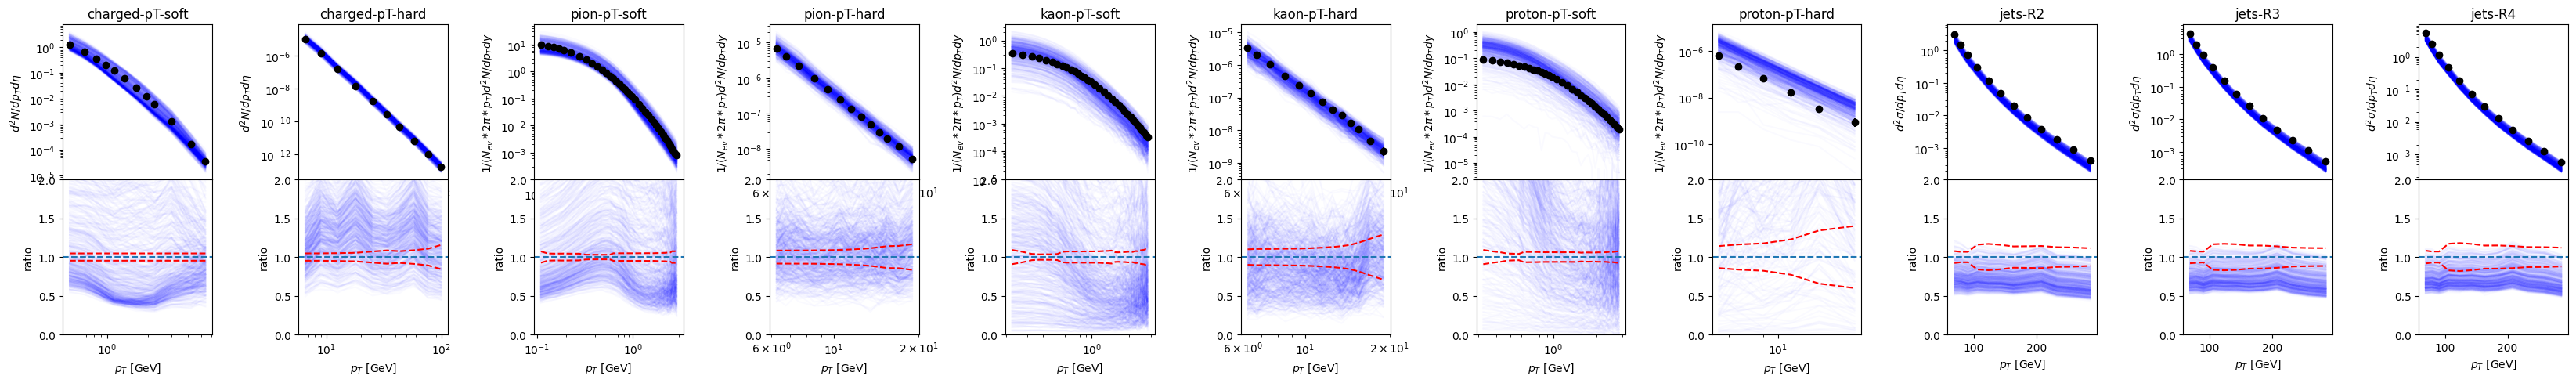

In [10]:
makeplot(ThisData, "Priors", outdir, logTrain=logTrain)

Posteriors

Making Posteriors...


/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:298: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axes[0][i].errorbar(DX, DY, yerr = DE, fmt='ro', label="Measurements", color='black')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:299: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:299: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/fun

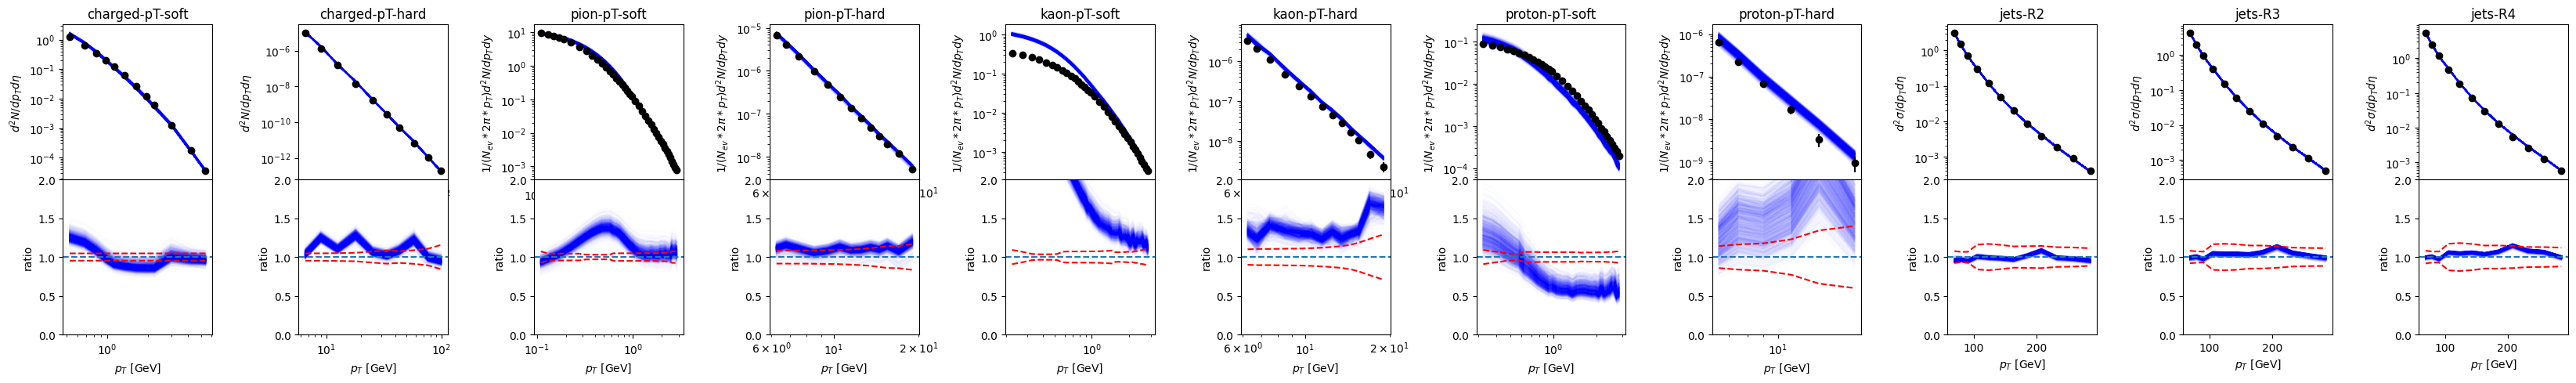

In [11]:
makeplot(ThisData, "Posteriors", outdir, samples=data["chain"], logTrain=logTrain)

Validation

/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:333: RuntimeWarning: divide by zero encountered in divide
  axes[0][i].plot(DX, np.exp(y1[0])/y2 if logTrain else y1[0]/y2, 'b-', alpha=10/linecount)


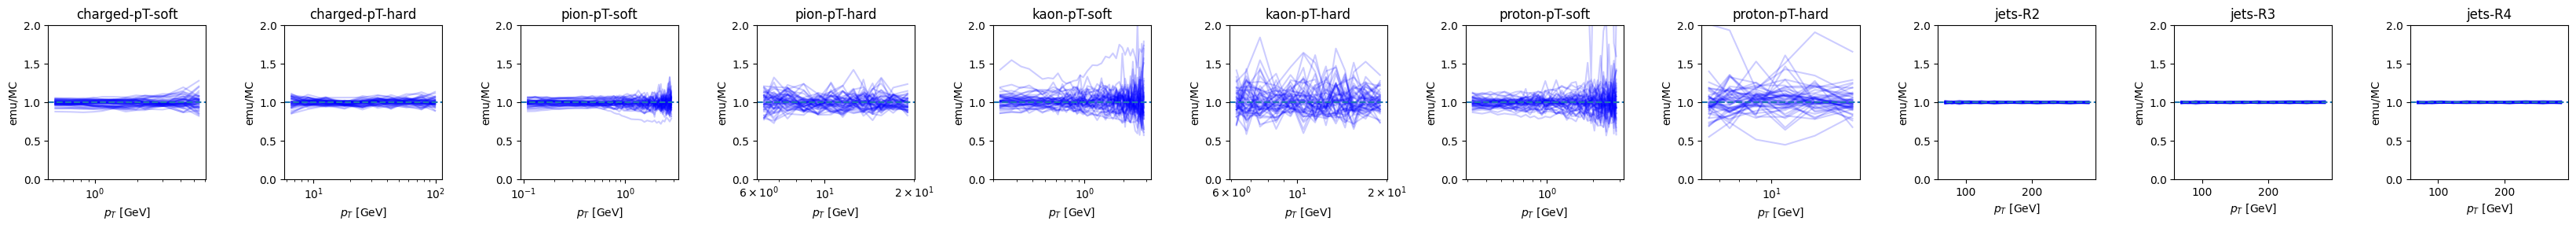

In [12]:
from src.data_objects import valData
updateCuts(ThisData,valData)
trimRanges(valData)
valData["Design"] = ReadDesign("/data/rjfgroup/rjf01/cameron.parker/runs/part-prop-val/LHC2760/QVir_Analysis/parameters.txt")
validationPlots(valData, ThisData, outdir, logTrain=logTrain)

Running closure test...
Adding PrPr2760charged-pT-soft to closure data
Adding PrPr2760charged-pT-hard to closure data
Adding PrPr2760pion-pT-soft to closure data
Adding PrPr2760pion-pT-hard to closure data
Adding PrPr2760kaon-pT-soft to closure data
Adding PrPr2760kaon-pT-hard to closure data
Adding PrPr2760proton-pT-soft to closure data
Adding PrPr2760proton-pT-hard to closure data
Adding PrPr2760jets-R2 to closure data
Adding PrPr2760jets-R3 to closure data
Adding PrPr2760jets-R4 to closure data
[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/pp2760-closure.pkl
[INFO][mcmc] Loading the model parameters space from input/ppDesign.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/pp2760/closure.pkl ...
[INFO][mcmc] Experimental dataset size: 198
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp27

Iter: 40it [1:33:01, 139.53s/it, beta=1, calls=506000, ESS=23317, logZ=482, logP=501, acc=0.711, steps=10, eff=1]           

[INFO][mcmc] Generate the posterior samples ...


[INFO][mcmc] Generate the evidence ...
Log evidence:  481.6295568963983
Log evidence error:  None
[INFO][mcmc] Writing pocoMC chains to file...


/home/rjfgroup/cameron.parker/.local/lib/python3.8/site-packages/scipy/optimize/_differentialevolution.py:382: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= -394.437
differential_evolution step 2: f(x)= -414.991
differential_evolution step 3: f(x)= -446.932
differential_evolution step 4: f(x)= -446.932
differential_evolution step 5: f(x)= -456.769
differential_evolution step 6: f(x)= -456.769
differential_evolution step 7: f(x)= -484.047
differential_evolution step 8: f(x)= -491.688
differential_evolution step 9: f(x)= -492.696
differential_evolution step 10: f(x)= -492.696
differential_evolution step 11: f(x)= -492.696
differential_evolution step 12: f(x)= -492.696
differential_evolution step 13: f(x)= -492.696
differential_evolution step 14: f(x)= -492.696
differential_evolution step 15: f(x)= -492.696
differential_evolution step 16: f(x)= -492.696
differential_evolution step 17: f(x)= -498.317
differential_evolution step 18: f(x)= -498.317
differential_evolution step 19: f(x)= -498.317
differential_evolution step 20: f(x)= -498.317
differential_evolution step 21: f(x)= -498.317
differential_evolution

/home/rjfgroup/cameron.parker/.local/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


[0.2539815  4.69936994 4.42378873 0.96152823 0.11596712 0.23656031
 0.11462967 1.73159744]
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][cor

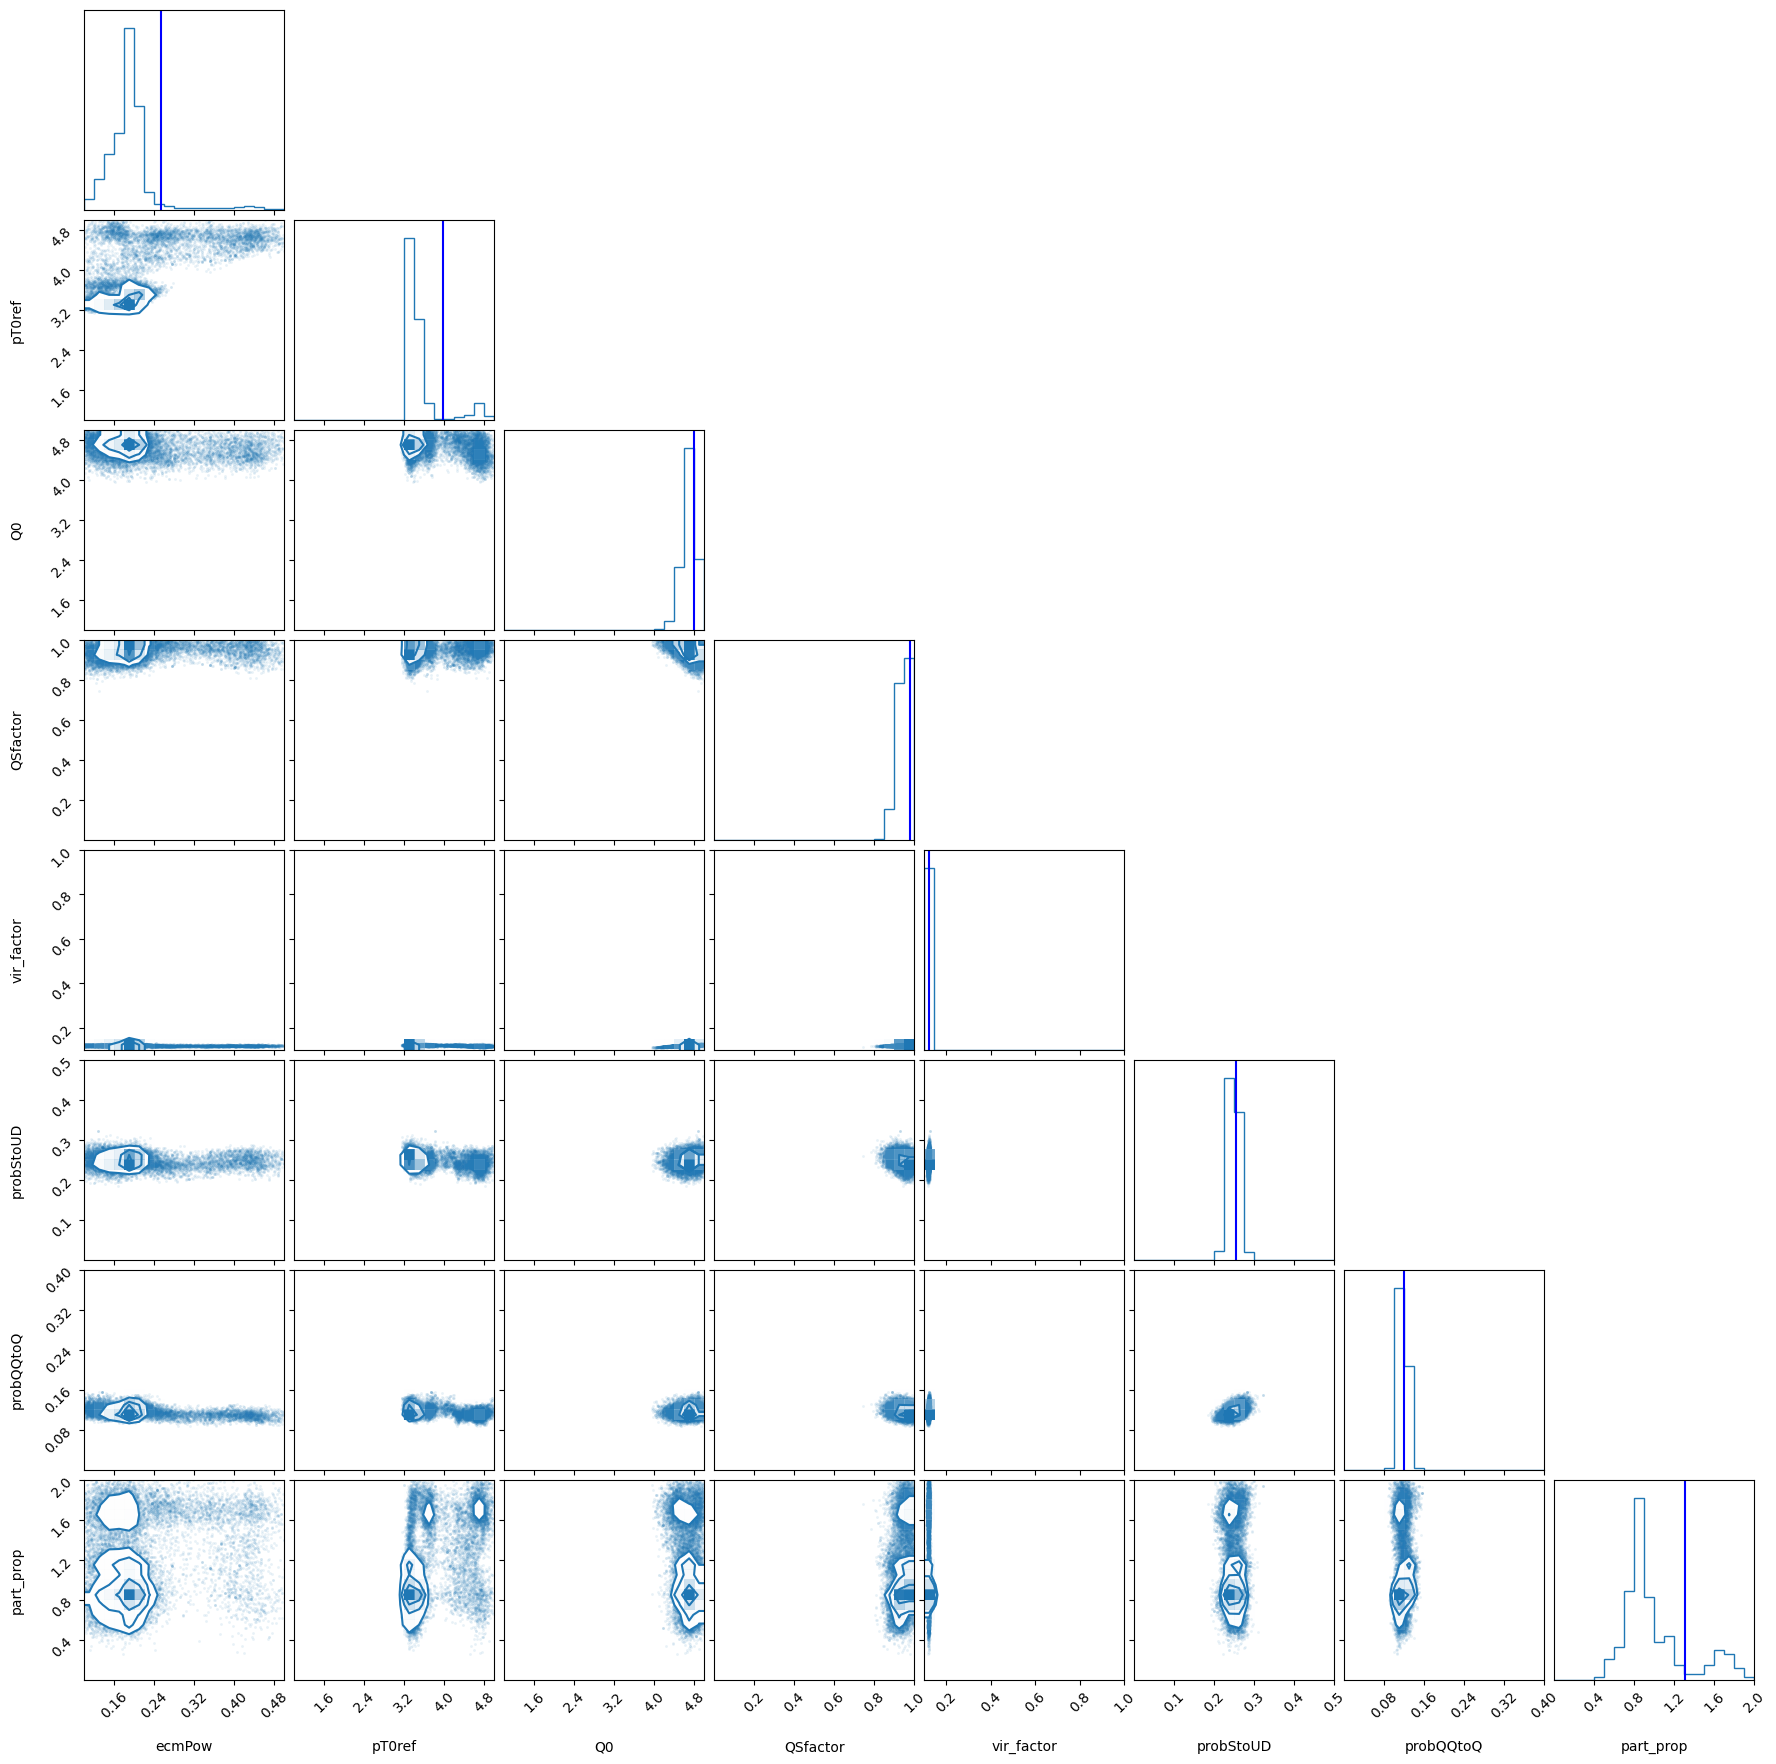

In [13]:
closureTest(ThisData, valData, outdir, model_par, runchain=True, logTrain=logTrain)